############################################################
# IGF2BP2 PROJECT – WGCNA
############################################################

# Author: Vishnu A M
# Lab: CLOCK Lab
# Institute: Indian Institute of Technology, Gandhinagar, India
#
# This notebook takes inputs generated from other scripts and uses it to plot

# Output: Figure panels corresponding to figure 1 and figure 2



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import fastcluster
from scipy.stats import pearsonr
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from adjustText import adjust_text
import warnings

## PCA PLotting  - Figure 1

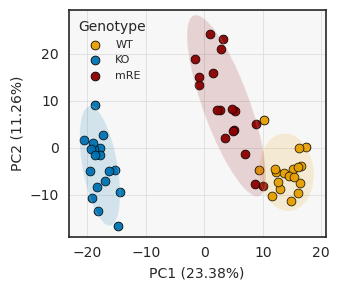

In [ ]:
# ===============================
# 🔧 Adjustable Parameters
# ===============================
FIGSIZE = (3.5, 3)
POINT_SIZE = 40
POINT_ALPHA = 0.95
EDGE_COLOR = "black"
EDGE_WIDTH = 0.6
LABEL_FONT_SIZE = 8
AXIS_FONT_SIZE = 10
TICK_FONT_SIZE = 10
LEGEND_FONT_SIZE = 8
LEGEND_TITLE_SIZE = 10
SHOW_ELLIPSE = True
ELLIPSE_ALPHA = 0.15
# FONT_FAMILY = "Helvetica"  # change to Helvetica if installed

# Choose marker shapes
GENOTYPE_MARKERS = {
    "WT": "o",
    "KO": "o",
    "mRE": "o"
}

GENOTYPE_COLORS = {
    "WT": "#E69F00",      # refined orange
    "KO": "#0072B2",      # journal blue
    "mRE": "#8B0000"      # dark red
}

# ===============================
# 1. Load PCA results
# ===============================
pca_scores = pd.read_csv("path/to/PCA_scores.csv")
pca_var = pd.read_csv("path/to/PCA_variance.csv")

pc1_var = pca_var.loc[0, "Variance"]
pc2_var = pca_var.loc[1, "Variance"]

# ===============================
# 2. Create Plot
# ===============================
sns.set_style("white")
# plt.rcParams["font.family"] = FONT_FAMILY

fig, ax = plt.subplots(figsize=FIGSIZE)

texts = []

for genotype in GENOTYPE_COLORS.keys():
    subset = pca_scores[pca_scores["genotype"] == genotype]
    
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=POINT_SIZE,
        c=GENOTYPE_COLORS[genotype],
        marker=GENOTYPE_MARKERS[genotype],
        edgecolor=EDGE_COLOR,
        linewidth=EDGE_WIDTH,
        alpha=POINT_ALPHA,
        label=genotype
    )
    
    # Add labels
    # for _, row in subset.iterrows():
        # texts.append(
            # ax.text(
                # row["PC1"],
                # row["PC2"],
                # row["samples"],
                # fontsize=LABEL_FONT_SIZE
            # )
        # )

# ===============================
# 3. Adjust labels with arrows (anti-clutter)
# ===============================
# adjust_text(
#     texts,
#     arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
#     expand_points=(1.2, 1.4)
# )

# ===============================
# 4. Optional confidence ellipses
# ===============================
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0),
                      width=ell_radius_x * 2,
                      height=ell_radius_y * 2,
                      fill=True,
                      **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

if SHOW_ELLIPSE:
    for genotype in GENOTYPE_COLORS.keys():
        subset = pca_scores[pca_scores["genotype"] == genotype]
        confidence_ellipse(
            subset["PC1"],
            subset["PC2"],
            ax,
            facecolor=GENOTYPE_COLORS[genotype],
            alpha=ELLIPSE_ALPHA
        )

# ===============================
# 5. Axis styling
# ===============================
ax.set_xlabel(f"PC1 ({pc1_var}%)", fontsize=AXIS_FONT_SIZE)
ax.set_ylabel(f"PC2 ({pc2_var}%)", fontsize=AXIS_FONT_SIZE)

ax.tick_params(axis='both', labelsize=TICK_FONT_SIZE)
ax.set_facecolor("#F7F7F7")

ax.grid(
    True,
    linestyle="-",
    linewidth=0.6,
    color="#DDDDDD"
)
# Thicker axis lines
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# ===============================
# 6. Legend styling
# ===============================
legend = ax.legend(
    frameon=False,
    fontsize=LEGEND_FONT_SIZE,
    title="Genotype",
    title_fontsize=LEGEND_TITLE_SIZE
)

# ===============================
# 7. Final touches
# ===============================
plt.tight_layout()
plt.savefig("path/to/PCA_plot_final.tiff",bbox_inches='tight', dpi=300, transparent=True)
plt.show()

## Module-trait association - Figure 1

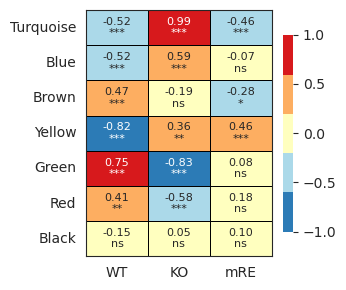

In [ ]:
# ===============================
# 🔧 Adjustable parameters
# ===============================
FIGSIZE = (3.5, 3)
# FONT_FAMILY = "TeX Gyre Heros"
AXIS_FONT_SIZE = 10
ANNOT_FONT_SIZE = 8
TITLE_FONT_SIZE = 16

# WGCNA-like palette
CMAP = sns.color_palette(
    ["#2C7BB6", "#ABD9E9", "#FFFFBF", "#FDAE61", "#D7191C"],
    as_cmap=True
)

# ===============================
# 1. Load data
# ===============================

#######################
# The following data comes from the output of the script named "Differential_rhythmicity_DryR.R"
#######################

df = pd.read_csv("path/to/08_module_trait_relationship_binarized/heatmap_data.csv", index_col=0)

# Identify module eigengenes and traits
module_cols = df.columns[:7]      # first 7 columns = modules
trait_cols = df.columns[7:]       # last columns = WT KO mRE

modules = df[module_cols]
traits = df[trait_cols]

# ===============================
# Compute correlations + p-values
# ===============================
cor_matrix = pd.DataFrame(index=module_cols, columns=trait_cols)
pval_matrix = pd.DataFrame(index=module_cols, columns=trait_cols)

for mod in module_cols:
    for trait in trait_cols:
        r, p = pearsonr(modules[mod], traits[trait])
        cor_matrix.loc[mod, trait] = r
        pval_matrix.loc[mod, trait] = p

cor_matrix = cor_matrix.astype(float)
pval_matrix = pval_matrix.astype(float)

# Reverse module order
cor_matrix = cor_matrix.iloc[::-1]
pval_matrix = pval_matrix.iloc[::-1]

# Capitalize module names
cor_matrix.index = [m.capitalize() for m in cor_matrix.index]
pval_matrix.index = cor_matrix.index

# ===============================
# Convert p-values to stars
# ===============================
def p_to_stars(p):
    if p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return "ns"

annot_matrix = cor_matrix.copy().astype(str)

for i in cor_matrix.index:
    for j in cor_matrix.columns:
        r = cor_matrix.loc[i, j]
        stars = p_to_stars(pval_matrix.loc[i, j])
        annot_matrix.loc[i, j] = f"{r:.2f}\n{stars}"



# ===============================
# 4. Plot WGCNA-style heatmap
# ===============================
sns.set_style("white")
# plt.rcParams["font.family"] = FONT_FAMILY

fig, ax = plt.subplots(figsize=FIGSIZE)

heatmap = sns.heatmap(
    cor_matrix,
    cmap=CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    annot=annot_matrix,
    annot_kws={"size": ANNOT_FONT_SIZE},
    fmt="",
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"shrink": 0.8}
)

# Axis styling
ax.set_xticklabels(ax.get_xticklabels(), rotation=0,
                   fontsize=AXIS_FONT_SIZE)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                   fontsize=AXIS_FONT_SIZE)

# Colorbar styling
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
# cbar.set_label("Pearson correlation", fontsize=10)

# Remove frame
for spine in ax.spines.values():
    spine.set_visible(True)


plt.tight_layout()



plt.savefig("path/to/Module_Trait_Correlation_Final.tiff", bbox_inches='tight', dpi=300, transparent=True)
plt.show()


## DryR plot - Figure 2

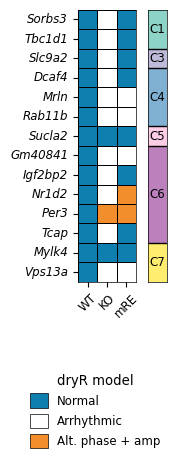

In [2]:

# -------------------------
# 1️⃣ Define Mapping & Load Data
# -------------------------
gene_to_community = {
    "Atp8a1": "Community 7", "Car3": "Community 4", "Nr1d2": "Community 6",
    "4930471C04Rik": "Community 4", "Cib2": "Community 7", "Gm40841": "Community 6",
    "Tiam1": "Community 5", "Tbc1d1": "Community 1", "Chrnb1": "Community 3",
    "Vps13a": "Community 7", "Mreg": "Community 5", "Rab11b": "Community 4",
    "Mrln": "Community 4", "Ttll7": "Community 3", "Dcaf4": "Community 4",
    "Gm11734": "Community 5", "Oplah": "Community 5", "Mylk4": "Community 7",
    "Aebp1": "Community 1", "BC004004": "Community 3", "Cpne2": "Community 7",
    "Pla2g7": "Community 3", "Sorbs3": "Community 1", "Slc9a2": "Community 3",
    "Igf2bp2": "Community 6", "Per3": "Community 6", "Sucla2": "Community 5",
    "Tcap": "Community 6"
}

# Load your file
file_path = "/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/outputs/dryr/turquoise/dryr_hubs_rhytmicity.tsv"
df = pd.read_csv(file_path, sep="\t")

# Apply mapping
df["Community"] = df["Gene"].map(gene_to_community)
df = df.dropna(subset=["Community"])

# -------------------------
# 2️⃣ Encode & Sort Data
# -------------------------
rhythm_map = {"normal": 0, "arrhythmic": 1, "alt_phase_amp": 2}
df_plot = df.copy()
df_plot["WT"] = df_plot["WT"].map(rhythm_map)
df_plot["KO"] = df_plot["KO"].map(rhythm_map)
df_plot["mRE"] = df_plot["mRE"].map(rhythm_map)

df_plot["Community"] = df_plot["Community"].str.replace("Community ", "C")
df_plot["Cnum"] = df_plot["Community"].str.replace("C", "").astype(int)
df_plot = df_plot.sort_values(["Cnum", "Gene"])

# -------------------------
# 3️⃣ Build Matrices
# -------------------------
heatmap_data = df_plot[["WT", "KO", "mRE"]]
heatmap_data.index = df_plot["Gene"]

cnum_factors, cnum_uniques = pd.factorize(df_plot["Cnum"])
community_vals = cnum_factors.reshape(-1, 1)

# -------------------------
# 4️⃣ Color Maps (Customizable)
# -------------------------
# Main heatmap colors
hex_normal = "#0E7FAF"
hex_arrhythmic = "#ffffff"
hex_alt = "#F28E2B"
rhythm_cmap = ListedColormap([hex_normal, hex_arrhythmic, hex_alt])

# ✅ MANUALLY SET COMMUNITY COLORS HERE
custom_community_colors = {
    1: "#8dd3c7",  # Pale green
    3: "#bebada",  # Lavender
    4: "#80b1d3",  # Light Blue
    5: "#fccde5",  # Light pink
    6: "#bc80bd",  # Light purple
    7: "#ffed6f"   # Pale yellow
}

# Build cmap dynamically based on the communities present in the data
community_palette = [custom_community_colors[c] for c in cnum_uniques]
community_cmap = ListedColormap(community_palette)

# -------------------------
# 5️⃣ Plot Layout & Width Settings
# -------------------------

# (width, height) in inches. Reduce width to make the whole image narrower.
fig = plt.figure(figsize=(1.8, 4)) # Reduced width to squeeze out the margins
main_heatmap_width = 3
community_strip_width = 1

# Squeezed wspace to 0.01
gs = fig.add_gridspec(1, 2, width_ratios=[main_heatmap_width, community_strip_width], wspace=0)
# --- AX1: Rhythm Heatmap (Left Panel) ---
ax1 = fig.add_subplot(gs[0])
sns.heatmap(
    heatmap_data,
    cmap=rhythm_cmap,
    cbar=False,
    linewidths=0.5,
    linecolor="black",
    square=True,
    ax=ax1
)

ax1.set_ylabel("")
ax1.set_xlabel("")

# ✅ Move ticks to the top
ax1.xaxis.tick_bottom() 

# ✅ Change ha="right" to ha="left" so the rotated text angles nicely upwards and outwards
ax1.set_xticklabels(["WT", "KO", "mRE"], rotation=45, ha="center", fontsize=8.5)
plt.setp(ax1.get_yticklabels(), rotation=0, style='italic', fontsize=8.5)

# --- AX0: Community Strip (Right Panel) ---
ax0 = fig.add_subplot(gs[1])
sns.heatmap(
    community_vals,
    cmap=community_cmap,
    cbar=False,
    linewidths=0,       # ✅ SET TO 0: Removes inner cell borders
    xticklabels=False,
    yticklabels=False,
    square=True,
    ax=ax0
)
ax0.set_ylabel("")


# ✅ Move the label position to the top
# ax0.xaxis.set_label_position('top')
# ax0.set_xlabel("Comm", rotation=45, labelpad=5, fontsize=8.5)

# Add text labels inside blocks
for i, cnum in enumerate(cnum_uniques):
    positions = np.where(df_plot["Cnum"] == cnum)[0]
    mid_pos = positions.mean() + 0.5
    ax0.text(0.5, mid_pos, f"C{cnum}", ha='center', va='center', 
              fontsize=8.5, color='black')

# -------------------------
# 6️⃣ Inter-Community Borders ONLY
# -------------------------
group_boundaries = np.where(np.diff(df_plot["Cnum"]))[0]

for boundary in group_boundaries:
    # ✅ Draw thick lines ONLY on the community strip (ax0)
    ax0.hlines(boundary + 1, *ax0.get_xlim(), colors="black", linewidth=1)

# Outer borders around the heatmaps
for ax in [ax0, ax1]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.5)

# -------------------------
# 7️⃣ Legend (Bottom)
# -------------------------
legend_elements = [
    Patch(facecolor=hex_normal, edgecolor="black", linewidth=0.5, label="Normal"),
    Patch(facecolor=hex_arrhythmic, edgecolor="black", linewidth=0.5, label="Arrhythmic"),
    Patch(facecolor=hex_alt, edgecolor="black", linewidth=0.5, label="Alt. phase + amp")
]



# Set ncol=1 to stack them vertically
fig.legend(
    handles=legend_elements,
    title="dryR model",       # <--- ADD THE TITLE HERE
    title_fontsize=9.5,       # <--- Adjust title size to stand out slightly
    loc="upper center",       
    ncol=1,                   
    frameon=False,
    bbox_to_anchor=(0.5, 0.08), 
    fontsize=8.5,
    handleheight=1.5,         
    handlelength=1.5          
)


# Increase the bottom margin (0.15 instead of 0.05) to fit the 3-row stacked legend
plt.tight_layout(rect=[0, 0.15, 1, 1]) 
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/outputs/dryr/turquoise/dryr_hubs_rhythmicity_heatmap_final.tiff", bbox_inches='tight', dpi=300, transparent=True)
plt.show()

## differential gene expression plot - Figure 2

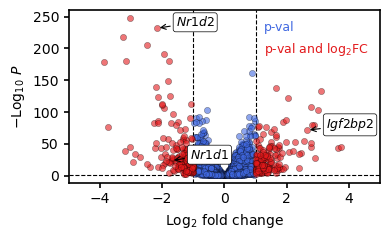

In [46]:
# Suppress warnings for log(0) if any p-values are exactly 0
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Load DESeq2 results
res_df = pd.read_csv("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/gse197726_salmon_deseq2_result/gse197726_salmon_deseq2_results.csv")

# Define thresholds
p_cutoff = 0.05
fc_cutoff = 1

# Handle NA values and exact zeros in padj to avoid infinity
res_df["padj"] = res_df["padj"].fillna(1)
res_df["neg_log10_padj"] = -np.log10(res_df["padj"].replace(0, np.finfo(float).eps))

# --------------------------------------------------------------------
# 1. Update Categorization to match the 4-color Target Image
# --------------------------------------------------------------------
res_df["category"] = "NS"
res_df.loc[
    (res_df["padj"] >= p_cutoff) & (res_df["log2FoldChange"].abs() > fc_cutoff), 
    "category"
] = "Log2 FC"
res_df.loc[
    (res_df["padj"] < p_cutoff) & (res_df["log2FoldChange"].abs() <= fc_cutoff), 
    "category"
] = "p-value"
res_df.loc[
    (res_df["padj"] < p_cutoff) & (res_df["log2FoldChange"].abs() > fc_cutoff), 
    "category"
] = "p-value and log2 FC"

# --------------------------------------------------------------------
# 2. Plotting Setup
# --------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4,2.5))

colors = {
    "NS": "#b3b3b3",                  # Grey
    "Log2 FC": "#4CAF50",             # Green
    "p-value": "#4169E1",             # Royal blue
    "p-value and log2 FC": "#E31A1C"  # Red
}

legend_labels = {
    "NS": "NS",
    "Log2 FC": r"log$_2$FC",
    "p-value": "p-val",
    "p-value and log2 FC": r"p-val and log$_2$FC"
}

zorders = {"p-value": 1, "p-value and log2 FC": 2}
categories = ["p-value", "p-value and log2 FC"]

for cat in categories:
    subset = res_df[res_df["category"] == cat]
    ax.scatter(
        subset["log2FoldChange"],
        subset["neg_log10_padj"],
        c=colors[cat],
        s=20,
        alpha=0.6,
        edgecolors="black",
        linewidths=0.3,
        label=legend_labels[cat],
        zorder=zorders[cat]
    )

# --------------------------------------------------------------------
# 3. Lines, Grids & Spines
# --------------------------------------------------------------------
ax.axhline(-np.log10(p_cutoff), color="black", linestyle="--", linewidth=0.8, zorder=0)
ax.axvline(fc_cutoff, color="black", linestyle="--", linewidth=0.8, zorder=0)
ax.axvline(-fc_cutoff, color="black", linestyle="--", linewidth=0.8, zorder=0)

ax.grid(False) # color="#E5E5E5", linestyle="-", linewidth=1, zorder=0
ax.set_axisbelow(True)


# Show all spines (closed box)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

    
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
# ax.spines['left'].set_linewidth(1.2)
# ax.spines['bottom'].set_linewidth(1.2)
ax.tick_params(width=1.2, labelsize=10)

# --------------------------------------------------------------------
# 4. Annotations with Bounding Boxes and ARROWS
# --------------------------------------------------------------------
genes_of_interest = ["Igf2bp2", "Nr1d1", "Nr1d2"]
texts = []

for _, row in res_df.iterrows():
    if row.get("symbol") in genes_of_interest:
        ax.annotate(
            rf"$\it{{{row['symbol']}}}$",
            xy=(row["log2FoldChange"], row["neg_log10_padj"]),     # point
            xytext=(row["log2FoldChange"] + 0.6, row["neg_log10_padj"] + 3),  # label position
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="black",
                linewidth=0.5
            ),
            arrowprops=dict(
                arrowstyle="->",
                color="black",
                lw=0.8
            ),
            zorder=5
        )


# --------------------------------------------------------------------
# 5. Labels and Legends
# --------------------------------------------------------------------
ax.set_xlabel(r"Log$_2$ fold change", fontsize=10)
ax.set_ylabel(r"$-$Log$_{10}$ $P$", fontsize=10)
ax.set_xlim(-5, 5)

leg = ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=9,
    handlelength=0,   # removes legend marker
    handletextpad=0.4
)

legend_color_map = {
    "p-val": "#4169E1",
    r"p-val and log$_2$FC": "#E31A1C"
}


for text in leg.get_texts():
    label = text.get_text()
    if label in legend_color_map:
        text.set_color(legend_color_map[label])

# remove invisible markers fully
for handle in leg.legend_handles:
    handle.set_visible(False)


plt.tight_layout()
plt.savefig("/home/shriyansh/Documents/IGF2BP2_PROJECT/clean_files_for_paper/gse197726_salmon_deseq2_result/volcano_plot_final.tiff", bbox_inches='tight', dpi=300, transparent=True)
plt.show()